# Time series of sea ice inside and outside of plume

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import warnings
warnings.filterwarnings("ignore", module='distributed')

In [2]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [3]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [4]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

In [5]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:46271")
client

<Client: 'tcp://127.0.0.1:46271' processes=8 threads=32, memory=123.95 GiB>

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
# carve out beaufort region
salt_beaufort = salt_da.isel(i=slice(450,750),j=slice(110,390))
theta_beaufort = theta_da.isel(i=slice(450,750),j=slice(110,390))
ice_beaufort = ice_da.isel(i=slice(450,750),j=slice(110,390))

HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(110,390))

### Calculate potential density

In [8]:
# Convert depth (m) to pressure (dbar)
p = gsw.p_from_z(HH_grid.Z, 70)  # Depth is negative

# Convert Practical Salinity (SP) to Absolute Salinity (SA)
SA = gsw.SA_from_SP(salt_da, p, salt_da.XC, salt_da.YC)  # Assume longitude = 0 if unknown

# Convert Potential Temperature to Conservative Temperature
CT = gsw.conversions.CT_from_pt(SA, theta_da)

# Calculate potential density anomaly referenced to 0 dbar (1000 is subtracted)
sigma0 = gsw.sigma0(SA, CT)

In [9]:
sigma0.name = 'potential_density'
sigma0.attrs['long_name'] = 'potential_density'

## 1. Select days after sea ice minimum each year and mask SIC>15%

In [10]:
ice_beaufort = ice_da.sel(time=slice('2014','2020')).isel(i=slice(450,750),j=slice(110,390))
beaufort_area = HH_grid.isel(i=slice(450,750),j=slice(110,390)).rAc

In [11]:
# calculating minimum based on extend (count grid cells where ice concentration >= 15% and sum their areas)

# salculate sea ice extent: sum the area of grid cells where SIC >= 15%
ice_extent = ((ice_beaufort >= 15) * beaufort_area).sum(dim=['i', 'j'])
ice_extent = ice_extent.where(ice_extent != 0)

# group by year
grouped = ice_extent.groupby("time.year")

# find the day of the minimum extent for each year
min_ice_dates = []
for year, data in grouped:
    sic_min_yr = data['time']
    min_day_tmp = sic_min_yr[data.argmin().values].values  # Get the time corresponding to min extent
    min_ice_dates.append(min_day_tmp)
    print(f"{year}: Minimum extent on {min_day_tmp}")

2014: Minimum extent on 2014-09-23T12:00:00.000000000
2015: Minimum extent on 2015-09-16T12:00:00.000000000
2016: Minimum extent on 2016-09-01T12:00:00.000000000
2017: Minimum extent on 2017-10-07T12:00:00.000000000
2018: Minimum extent on 2018-09-21T12:00:00.000000000
2019: Minimum extent on 2019-09-24T12:00:00.000000000
2020: Minimum extent on 2020-09-06T12:00:00.000000000


In [12]:
# generate daily timestamps from each min date to Dec 31 of that year
date_arrays = [np.arange(np.datetime64(date), np.datetime64(f"{str(date)[:4]}-12-31") + np.timedelta64(1, 'D'), np.timedelta64(1, 'D'))
               for date in min_ice_dates]

# concatenate into one array
full_date_array = np.concatenate(date_arrays)

In [13]:
# select days after sea ice minimum for SIC and salinity

# select all timesteps after sea ice minimum each year
ice_yrs = ice_beaufort.sel(time=full_date_array)
# salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,8)) # only upper 12 m
salt_yrs = salt_beaufort.sel(time=full_date_array).isel(k=slice(0,7)) # only upper 10 m

In [14]:
# look at depth of grid cell center and bottom of grid cell
print(salt_yrs.Z.values)
print(HH_grid.isel(k_u=slice(0,7)).Zu.values)

[-0.5   -1.57  -2.79  -4.185 -5.78  -7.595 -9.66 ]
[ -1.    -2.14  -3.44  -4.93  -6.63  -8.56 -10.76]


In [15]:
# list to store yearly masks
mask_list = []

for date in min_ice_dates:
    year = str(date.astype('datetime64[Y]'))  # Extract year as a string
    
    # select all days from the minimum ice date to Dec 31
    yearly_data = ice_yrs.sel(time=slice(str(date), f"{year}-12-31"))

    # get sea ice concentration on the minimum ice date
    sic_min_day = ice_yrs.sel(time=date)

    # create a mask for grid cells where sic >= 15% on the minimum ice date
    mask = sic_min_day >= 15  # 2D (i, j)

    # expand mask along time dimension to match yearly_data
    mask_expanded = mask.expand_dims(dim={"time": yearly_data.time}, axis=0)

    # store in list
    mask_list.append(mask_expanded)

# combine all yearly masks
sic_yrs_mask = xr.concat(mask_list, dim="time").combine_first(ice_yrs * 0)  # Align time with ice_yrs

# apply mask to sea ice ds
land_sic_mask_yr = (~sic_yrs_mask.astype(bool)) & (HH_grid.isel(i=slice(450,750),j=slice(110,390),k=0).mask_basin)
ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)

## 2. Calculate FWC and bin data into 100 bins

In [16]:
def calculate_fwc(salt_da, salt_ref, dz):
    """
    Calculate the freshwater content (fwc)

    Parameters:
    salt_da (xr.DataArray): Salinity data array with a 'k' dimension.
    salt_ref (float): Reference salinity value.
    dz (xr.DataArray): Layer thickness data array with the same 'k' dimension.

    Returns:
    xr.DataArray: Freshwater content summed over the 'k' dimension.
    """
    fwc = ((salt_ref - salt_da) / salt_ref * dz).sum(dim='k')
    return fwc

In [17]:
# calculate FWC

# define reference salinity
salt_ref = 34.8

# dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,8)) # upper 12
dz = HH_grid.isel(i=slice(450,750),j=slice(110,390)).drF.isel(k=slice(0,7)) # upper 10
fwc_beaufort_yrs = calculate_fwc(salt_yrs, salt_ref, dz)

In [18]:
# mask land grid cells and where SIC>15% on ice minimum date
# ice_yrs_masked = ice_yrs.where(land_sic_mask_yr)
fwc_yrs_masked = fwc_beaufort_yrs.where(land_sic_mask_yr)

#### 2014

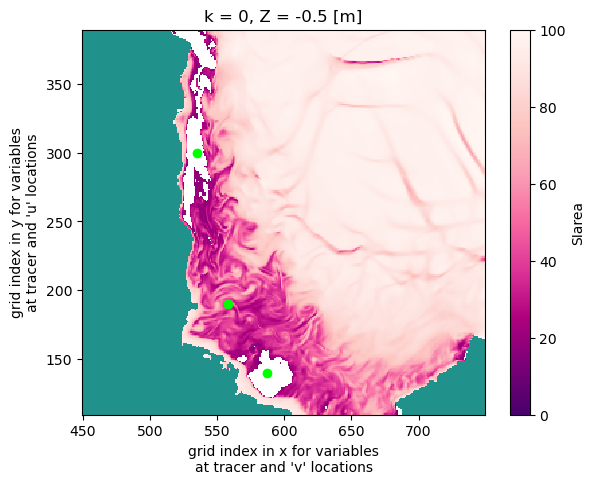

In [128]:
ice_beaufort.sel(time='2014-11-02').where(ice_beaufort.sel(time='2014-11-02')>15).plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[6.5,5]);
plt.scatter(535,300,color='lime');
plt.scatter(558,190,color='lime');
plt.scatter(587,140,color='lime');

HH_land_beaufort.plot(add_colorbar=False);

# plt.xlim(500,600)
# plt.ylim(110,250);

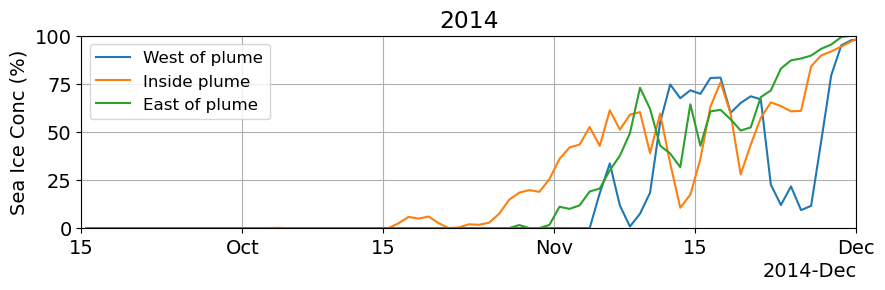

In [138]:
plt.rcParams['font.size'] = 14

fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=535,j=300).sel(time=slice('2014-09-15','2014-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=558,j=190).sel(time=slice('2014-09-15','2014-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=587,j=140).sel(time=slice('2014-09-15','2014-12-01')).plot(ax=ax, label='East of plume');

plt.title('2014')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2014-09-15'),np.datetime64('2014-12-01'))
plt.legend(fontsize=12);

#### 2015

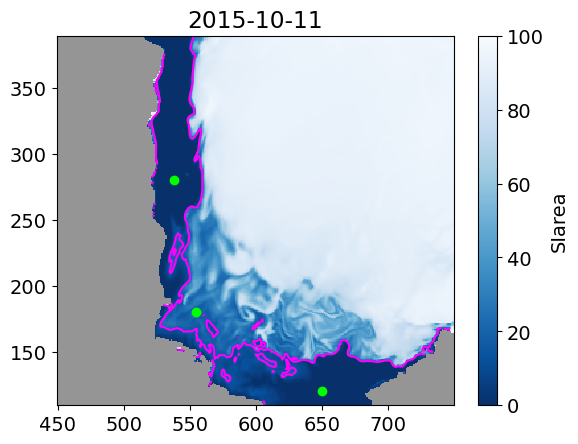

In [165]:
ice_beaufort.sel(time='2015-10-11').plot(vmin=0,vmax=100,cmap='Blues_r');
ice_beaufort.sel(time='2015-10-11').isel(time=0).plot.contour(levels=[15],colors='magenta');
plt.scatter(538,280,color='lime');
plt.scatter(555,180,color='lime');
plt.scatter(650,120,color='lime');

HH_land_beaufort.plot(cmap='Grays',add_colorbar=False);

plt.xlabel("")
plt.ylabel("");

plt.title("2015-10-11");

# plt.xlim(500,600)
# plt.ylim(110,250);

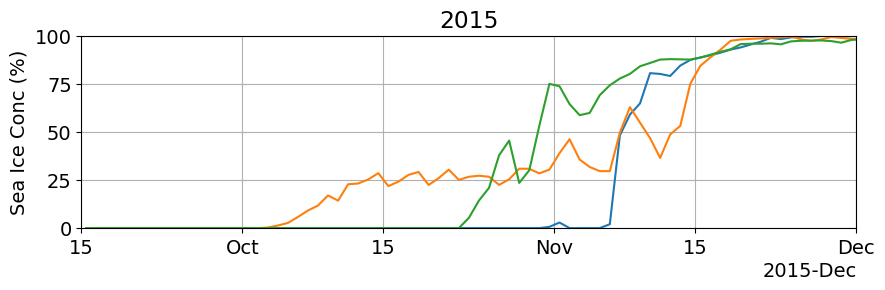

In [140]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=538,j=280).sel(time=slice('2015-09-15','2015-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=555,j=180).sel(time=slice('2015-09-15','2015-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=650,j=120).sel(time=slice('2015-09-15','2015-12-01')).plot(ax=ax, label='East of plume');

plt.title('2015')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2015-09-15'),np.datetime64('2015-12-01'));
# plt.legend(fontsize=12);

#### 2016

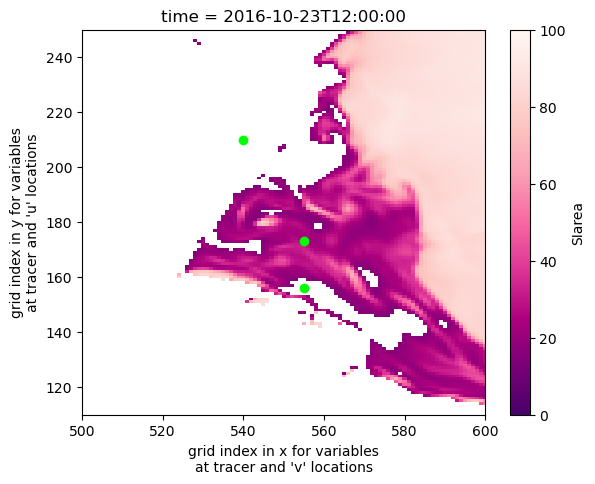

In [105]:
ice_beaufort.sel(time='2016-10-23').where(ice_beaufort.sel(time='2016-10-23')>15).plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[6.5,5]);
plt.scatter(540,210,color='lime');
plt.scatter(555,173,color='lime');
plt.scatter(555,156,color='lime');

plt.xlim(500,600)
plt.ylim(110,250);

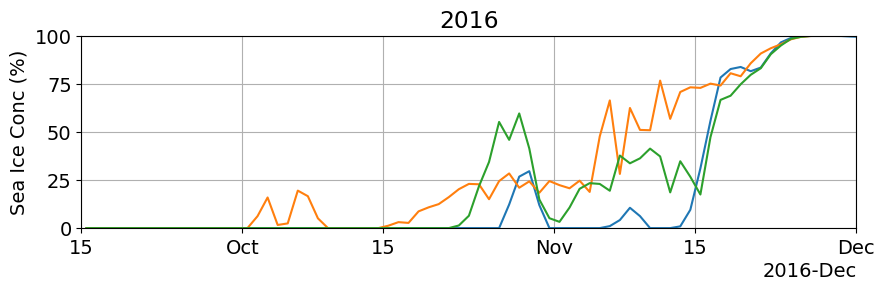

In [142]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=540,j=230).sel(time=slice('2016-09-15','2016-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=555,j=175).sel(time=slice('2016-09-15','2016-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=555,j=156).sel(time=slice('2016-09-15','2016-12-01')).plot(ax=ax, label='East of plume');

plt.title('2016')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2016-09-15'),np.datetime64('2016-12-01'));
# plt.legend(fontsize=12);

#### 2017

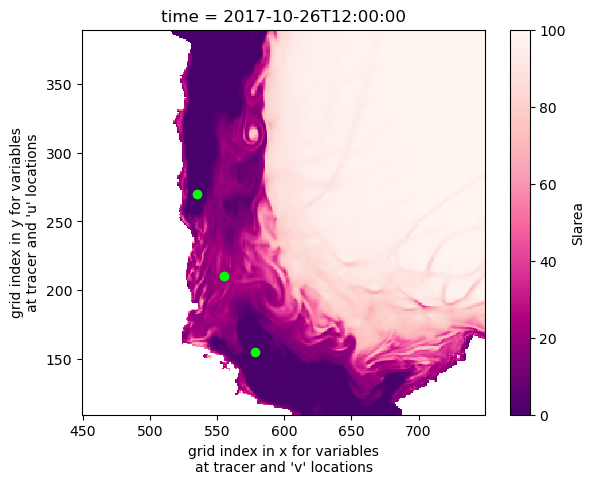

In [78]:
ice_beaufort.sel(time='2017-10-26').plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[6.5,5]);
plt.scatter(535,270,color='lime');
plt.scatter(555,210,color='lime');
plt.scatter(578,155,color='lime');

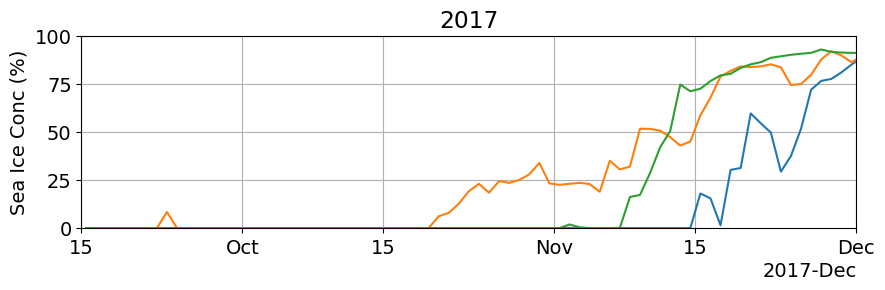

In [144]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=535,j=270).sel(time=slice('2017-09-15','2017-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=555,j=210).sel(time=slice('2017-09-15','2017-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=578,j=155).sel(time=slice('2017-09-15','2017-12-01')).plot(ax=ax, label='East of plume');

plt.title('2017')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2017-09-15'),np.datetime64('2017-12-01'));
# plt.legend(fontsize=12);

#### 2018

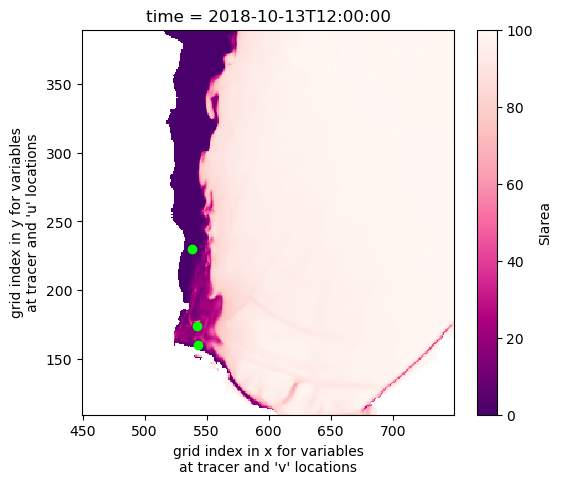

In [66]:
ice_beaufort.sel(time='2018-10-13').plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[6,5]);
plt.scatter(538,230,color='lime');
plt.scatter(542,174,color='lime');
plt.scatter(543,160,color='lime');

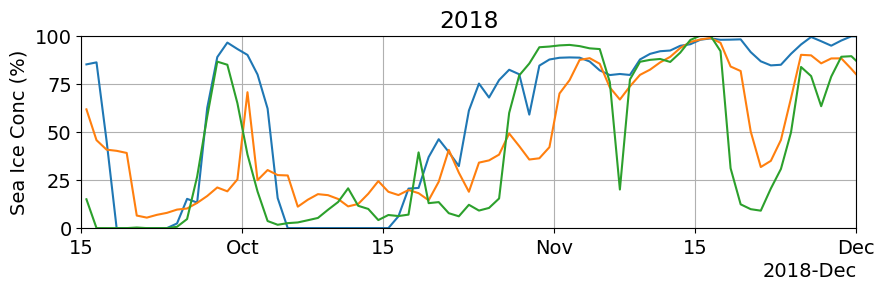

In [145]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=538,j=230).sel(time=slice('2018-09-15','2018-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=542,j=174).sel(time=slice('2018-09-15','2018-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=543,j=160).sel(time=slice('2018-09-15','2018-12-01')).plot(ax=ax, label='East of plume');

plt.title('2018')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2018-09-15'),np.datetime64('2018-12-01'));
# plt.legend(fontsize=12);

#### 2019

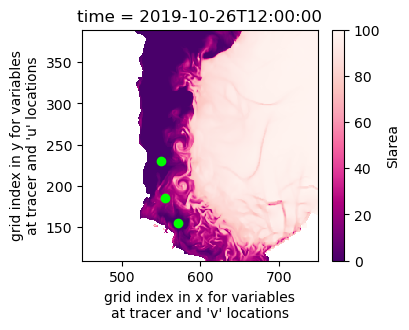

In [25]:
ice_beaufort.sel(time='2019-10-26').plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[3.8,3]);
plt.scatter(550,230,color='lime');
plt.scatter(555,185,color='lime');
plt.scatter(572,155,color='lime');

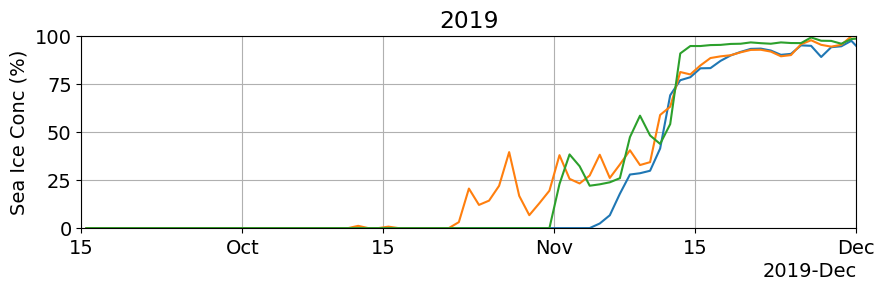

In [147]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=550,j=230).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=555,j=185).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=572,j=155).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='East of plume');

plt.title('2019')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2019-09-15'),np.datetime64('2019-12-01'));
# plt.legend(fontsize=12);

#### 2020

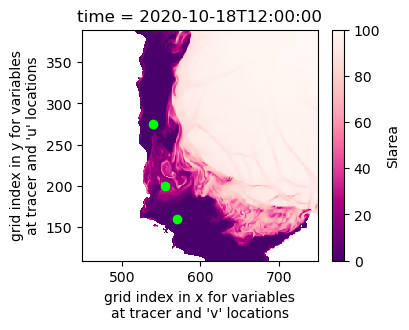

In [52]:
ice_beaufort.sel(time='2020-10-18').plot(vmin=0,vmax=100,cmap='RdPu_r',figsize=[3.8,3]);
plt.scatter(540,275,color='lime');
plt.scatter(555,200,color='lime');
plt.scatter(570,160,color='lime');

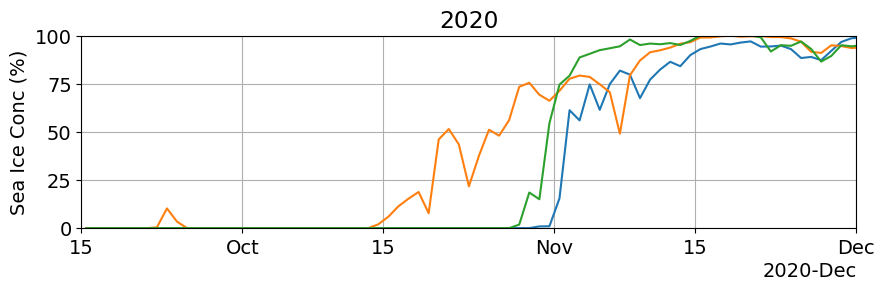

In [149]:
fig, ax = plt.subplots(1,1,figsize=[10,2.5])

ice_beaufort.sel(i=540,j=275).sel(time=slice('2020-09-15','2020-12-01')).plot(ax=ax, label='West of plume')
ice_beaufort.sel(i=555,j=200).sel(time=slice('2020-09-15','2020-12-01')).plot(ax=ax, label='Inside plume')
ice_beaufort.sel(i=570,j=160).sel(time=slice('2020-09-15','2020-12-01')).plot(ax=ax, label='East of plume');

plt.title('2020')
plt.grid()
plt.xlabel("")
plt.ylabel('Sea Ice Conc (%)')
plt.ylim(0,100)
plt.xlim(np.datetime64('2020-09-15'),np.datetime64('2020-12-01'));
# plt.legend(fontsize=12);

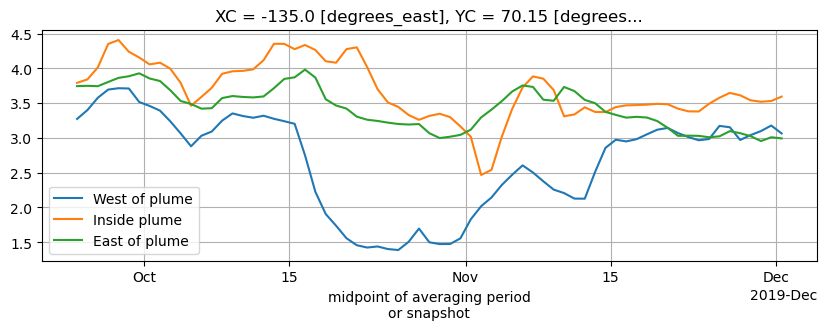

In [39]:
fig, ax = plt.subplots(1,1,figsize=[10,3])

fwc_yrs_masked.sel(i=550,j=230).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='West of plume')
fwc_yrs_masked.sel(i=555,j=185).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='Inside plume')
fwc_yrs_masked.sel(i=572,j=155).sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='East of plume');

plt.grid()
# plt.ylim(0,100)
plt.legend();

### Calculate OHC in ML

In [40]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
        salinity (array): salinity (PSU)
        temperature (array): temperature (°C)
        depth (array): depth values (m, negative downward)
        lon (float): longitude for SA calculation
        lat (float): latitude for pressure calculation
    
    Returns:
        cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [41]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Parameters:
    sigma0_array (xarray.DataArray): Potential density dataset with dimensions (time, k).
    density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    xarray.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array, threshold_idx

In [42]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Parameters:
    ----------
    temp : xarray.DataArray (time, k)
        2D array of temperature (°C) with dimensions ['time', 'k'].
    salinity : xarray.DataArray (time, k)
        2D array of salinity (PSU) with dimensions ['time', 'k'].
    density : xarray.DataArray (time, k)
        2D array of seawater density (kg/m³) with dimensions ['time', 'k'].
    layer_thickness : xarray.DataArray (k)
        1D array representing the thickness of each vertical layer (m).
    threshold_idx : xarray.DataArray (time)
        1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    -------
    ohc : xarray.DataArray (time, XC, YC)
        3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m²).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z.values, lon=temp.XC.values, lat=temp.YC.values)

    # Given array of indices
    indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [43]:
cell_thickness = HH_grid.drF

i_west=550
j_west=230

i_plume=555
j_plume=185

i_east=572
j_east=155

In [53]:
salt_pt_west = salt_beaufort.sel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_west = theta_beaufort.sel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_west = sigma0.sel(i=i_west,j=j_west).sel(time=slice('2019-08-01','2019-12-01')) + 1000 # convert to pot density from potential density anomaly

In [56]:
salt_pt_plume = salt_beaufort.sel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_plume = theta_beaufort.sel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_plume = sigma0.sel(i=i_plume,j=j_plume).sel(time=slice('2019-08-01','2019-12-01')) + 1000

In [57]:
salt_pt_east = salt_beaufort.sel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
theta_pt_east = theta_beaufort.sel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01'))
density_pt_east = sigma0.sel(i=i_east,j=j_east).sel(time=slice('2019-08-01','2019-12-01')) + 1000

In [58]:
# calculate mld and the index of the mld along k coord
mld_pt_west, threshold_idx_west = calculate_mld(density_pt_west, density_threshold=0.03)
mld_pt_plume, threshold_idx_plume = calculate_mld(density_pt_plume, density_threshold=0.03)
mld_pt_east, threshold_idx_east = calculate_mld(density_pt_east, density_threshold=0.03)

In [59]:
# calculate OHC
ohc_mld_west = calculate_ohc(theta_pt_west, salt_pt_west, density_pt_west, cell_thickness, threshold_idx_west).compute()
ohc_mld_plume = calculate_ohc(theta_pt_plume, salt_pt_plume, density_pt_plume, cell_thickness, threshold_idx_plume).compute()
ohc_mld_east = calculate_ohc(theta_pt_east, salt_pt_east, density_pt_east, cell_thickness, threshold_idx_east).compute()

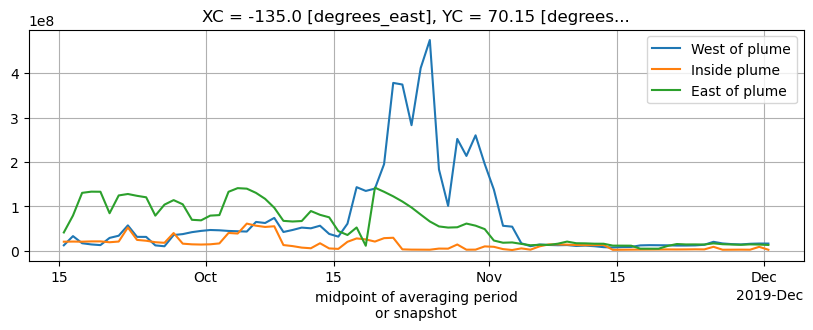

In [60]:
fig, ax = plt.subplots(1,1,figsize=[10,3])

ohc_mld_west.sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='West of plume')
ohc_mld_plume.sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='Inside plume')
ohc_mld_east.sel(time=slice('2019-09-15','2019-12-01')).plot(ax=ax, label='East of plume');

plt.grid()
# plt.ylim(0,100)
plt.legend();

## Isolate plume using freshwater content

In [67]:
fwc_fall = fwc_beaufort_yrs.sel(time=slice('2019-08-01','2019-12-01'))

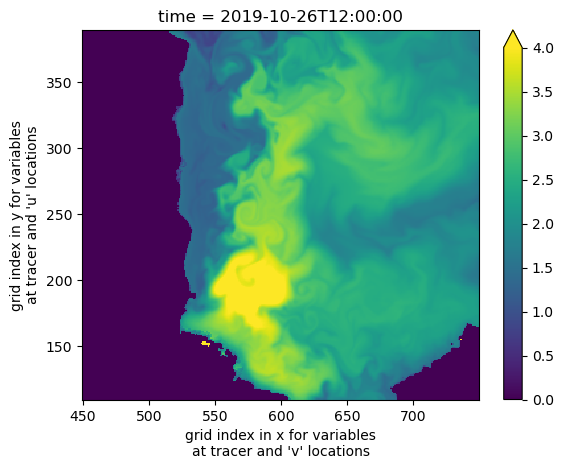

In [79]:
fwc_fall.sel(time='2019-10-26').plot(vmin=0,vmax=4);

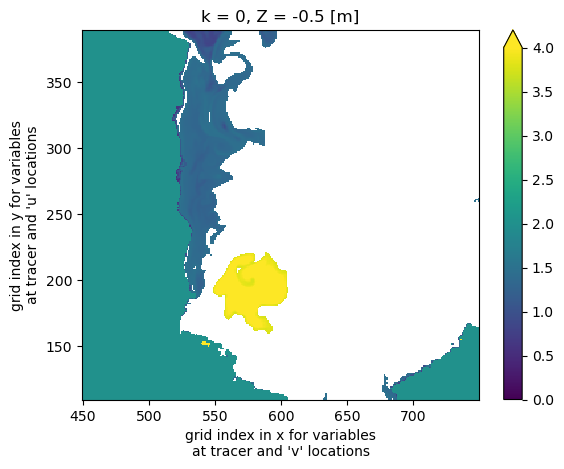

In [91]:
fwc_fall.where(fwc_fall>3.75).sel(time='2019-10-26').plot(vmin=0,vmax=4);
fwc_fall.where(fwc_fall<1.5).sel(time='2019-10-26').plot(vmin=0,vmax=4, add_colorbar=False);
# ice_beaufort.sel(time='2019-10-26').where(ice_beaufort.sel(time='2019-10-26')>15).plot(vmin=0,vmax=100);
HH_land_beaufort.plot(add_colorbar=False);

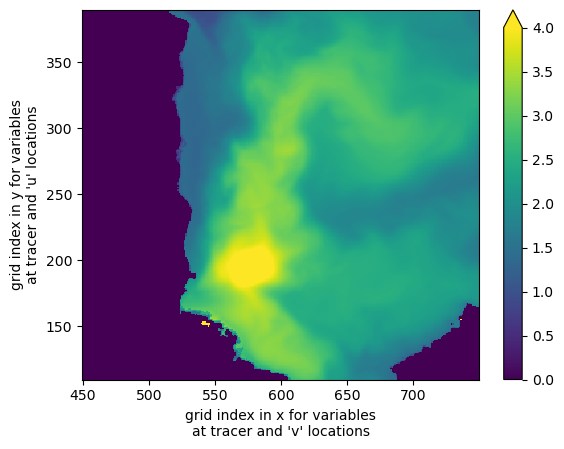

In [95]:
fwc_fall.mean(dim='time').plot(vmin=0,vmax=4);

In [105]:
fwc_fall_mean = fwc_fall.mean(dim='time')

fwc_masked_fall = fwc_yrs_masked.sel(time=slice('2019-08-01','2019-12-01'))
fwc_masked_fall_mean = fwc_masked_fall.mean(dim='time')

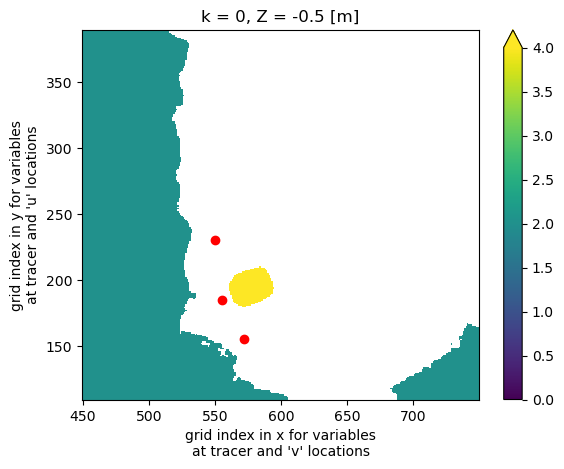

In [120]:
fwc_masked_fall_mean.where(fwc_masked_fall_mean>4).plot(vmin=0,vmax=4);
plt.scatter(550,230,color='r');
plt.scatter(555,185,color='r');
plt.scatter(572,155,color='r');
HH_land_beaufort.plot(add_colorbar=False);

In [118]:
fwc_plume = fwc_masked_fall.where(fwc_masked_fall>4)
sic_plume_avg = ice_beaufort.sel(time=slice('2019-08-01','2019-12-01')).where(fwc_masked_fall>4).mean(dim=['i','j'])
sic_plume_std = ice_beaufort.sel(time=slice('2019-08-01','2019-12-01')).where(fwc_masked_fall>4).std(dim=['i','j'])

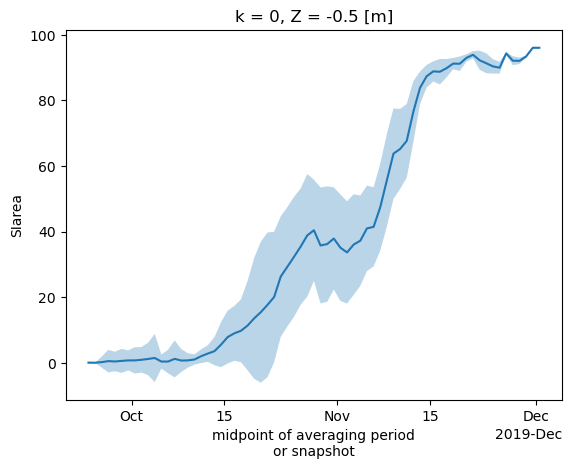

In [119]:
# Plot mean with global std shading
sic_plume_avg.plot(label='FWC over 3.5m')
plt.fill_between(sic_plume_avg.time, sic_plume_avg - sic_plume_std, sic_plume_avg + sic_plume_std, alpha=0.3)